# Overfitting:

-  When a model performs exceptionally well on the training data but poorly on unseen data, it is said to be overfitting. This occurs when the model learns not only the underlying patterns in the training data but also the noise and random fluctuations, leading to a lack of generalization.

# In case of Linear Regression what does overfitting exactly mean?

- In LR we find the best fit line (find the weights and off-set)

- And **weights** means how the model responds to changes in the input features (or $y = mx + b$, $m$ is the weight and $b$ is the off-set, so $y$ ko nikalne mei $x$ ka kitna effect hai, wo weight se pata chalta hai)

- For an **overfitted** LR model, **the value of weights will be very high**. This is because the model is trying to fit the training data as closely as possible, which can lead to a very steep line that captures the noise in the data rather than the underlying trend.

- For **underfitted** LR model, **the value of weights will be very low**. This is because the model is not capturing the underlying trend in the data and is instead fitting a line that is too flat.

### So, agar aapko overfitting kam karna hai, iska ek hi meaning hai ki hume weights ko kam karna hai

- Pr bohot jada kam karne se underfitting ho jayega, toh hume ek balance banana hoga.

# Ridge Regression/L2 Regularization:

- Ridge regression is a type of linear regression that includes a regularization term to prevent overfitting.

- The regularization term is the sum of the squares of the weights, multiplied by a regularization hyperparameter (lambda) added to the cost function.

## Example for 1-dimensional data:

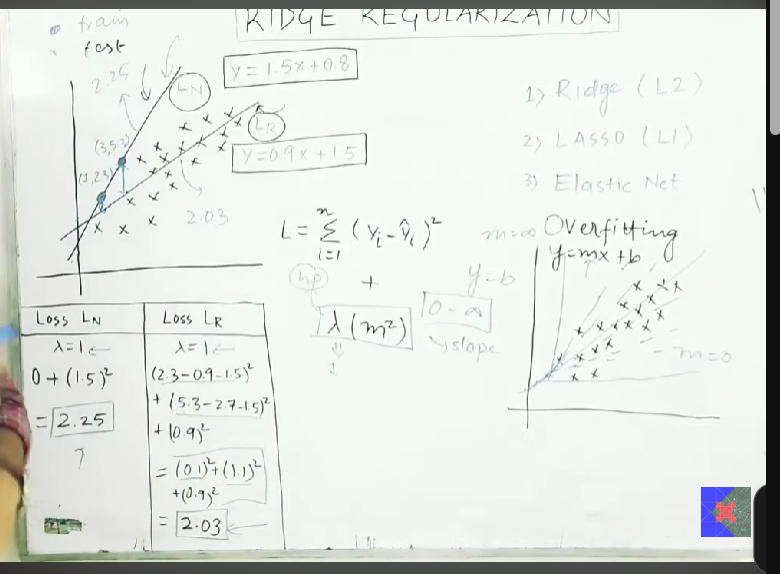

- As you can see in the pic, there are 2 training points, so the best line will be the line passing through both, but if you see the test points, its clear that its overfitting.

- So we somehow need to convince our model to take the $L_R$ line instead of $L_N$ line

- <span style="color:green"> **That is only possible if we can show that the cost function for $L_R$ is less than the cost function for $L_N$ for the training data, and that is only possible if we add a regularization term to the cost function.** </span>

- So see the calculation oh the bottom side of the whiteboard, the cost function for $L_R$ is less than the cost function for $L_N$ because of the regularization term

- Although bias thoda badh jayega, but variance bahut kam ho jayega, toh overall model ki performance improve ho jayegi.

- And regularization ka kaam hi yhi h, to balance the bias-variance tradeoff and prevent overfitting.


# Generalized form:

- The cost function for ridge regression is:

  $$
  J(\beta_0, \beta_1, \ldots, \beta_n) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 + \lambda \sum_{j=1}^{n} \beta_j^2
  $$

  - where $\hat{y}$ is the predicted value, $y$ is the actual value, $\beta_0$ is the intercept, $\beta_1, \ldots, \beta_n$ are the weights, and $\lambda$ is the regularization hyperparameter.

  - $m$ is the number of rows in the training data, and $n$ is the number of features.

  - The value of $\lambda$ can be tuned to control the amount of regularization. (it varies from 0 to $\infty$)

- Because of the regularization term, line with higher weights will have a higher cost, so the model will be encouraged to find a line with lower weights, which will help to prevent overfitting.

# Why it is known as L2 regularization?

- Because the regularization term is the sum of the squares of the weights, which is also known as the L2 norm of the weights.

- L1 norm means the sum of the absolute values of the weights, which is used in Lasso regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X=data.data
y=data.target

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

- Solving using Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [7]:
L.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [9]:
y_pred=L.predict(X_test)

In [10]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953252


- Using Ridge Regression

In [27]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=0.01) # alpha is the hyperparameter that controls the strength of the regularization.

- To decide the value of $\lambda$, we can use techniques like cross-validation to find the optimal value that minimizes the cost function on the validation set.

- Or try different values of $\lambda$ and see which one gives the best performance on the test set.

In [28]:
R.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [29]:
print(R.coef_)
print(R.intercept_)

[  26.26181052 -240.39934227  496.57507972  326.6599829  -420.98179086
  137.89180358  -53.05692237  194.22314385  581.45028172   94.31369289]
152.08329034119228


In [30]:
y_pred1=R.predict(X_test)

In [31]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score 0.5230847087541541
RMSE 48.5102842644092


- Overfitting and underfitting kese hota hai in Ridge Regression?

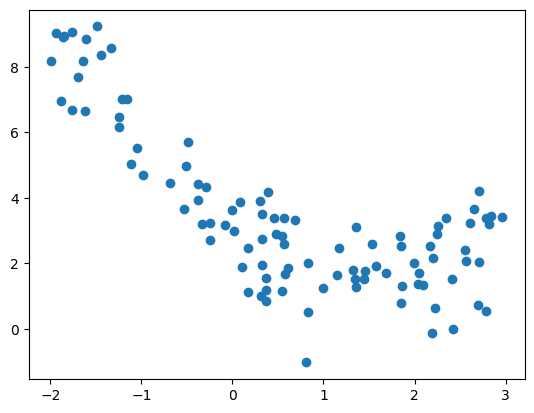

In [16]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

- Trying to fit a degree 16 polynomial to the degree 2 dataset, with
    - $\lambda = 0$ (no regularization, so bohot jada overfitting) 
    - $\lambda = 20$ (some regularization, trying to find a balance between bias and variance)
    - $\lambda = 200$ (a lot of regularization, underfitting, because the model is not able to capture the underlying trend in the data)

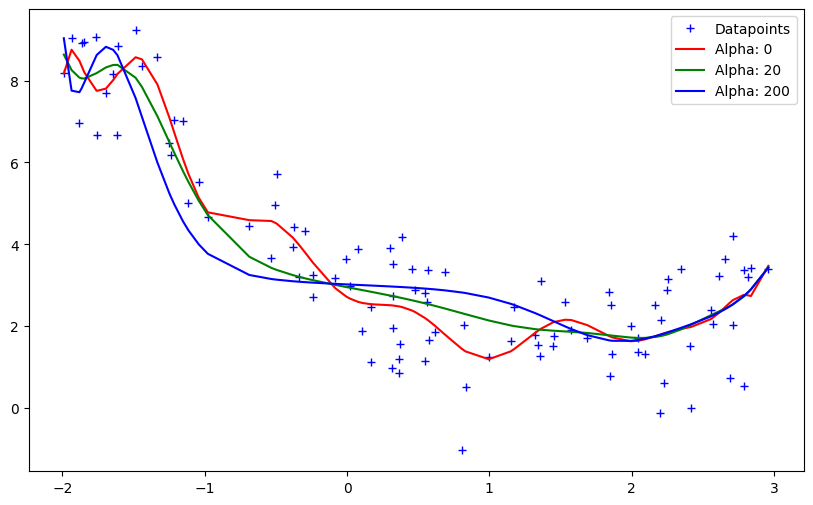

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()